# Microscope Design Curves (Unified)

This notebook supersedes:
- `intermediate_lens_magnification_fit.ipynb`
- `condenser_lens_spotsize_fit.ipynb`

It unifies both calibration workflows with a shared minimal core:
- shared transfer-matrix composition (`temgym_core.transfer_matrices`)
- shared scalar root solve helper
- shared focal-to-current and bounds checks

No JSON export is performed in this version.

## 1) Config

In [9]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import PchipInterpolator
import pandas as pd

from temgym_core.transfer_matrices import propagation_matrix, lens_matrix
from temgym_core.constants import compute_Rc_from_voltage

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

# -----------------------------
# Global electrical config
# -----------------------------
I_fs_A = 2.0
U_accel_V = 200e3
Rc_phys = float(compute_Rc_from_voltage(U_accel_V))

# -----------------------------
# Mode A: Intermediate-lens targets and geometry
# -----------------------------
M_obj = 80.0
M_proj = 100.0
target_system_mags = np.array([30000, 50000, 100000, 300000, 600000], dtype=float)
M_il_targets = target_system_mags / (M_obj * M_proj)
invert_image = True

geometry_il = {
    'd_obj_to_il1': 10e-3,
    'd_il1_to_il2': 52e-3,
    'd_il2_to_il3': 62e-3,
    'd_il3_to_image': 48.75e-3,
}

turns_il = {'IL1': 3000, 'IL2': 2000, 'IL3': 2000}
Gc_phys_il = {'IL1': 8.0e-6, 'IL2': 8.0e-6, 'IL3': 8.0e-6}
reference_i_norm_il = {'IL1': 0.9, 'IL2': 0.9, 'IL3': 0.9}

Gc_eff_il = {k: Gc_phys_il[k] * (turns_il[k] * I_fs_A) ** 2 for k in ('IL1', 'IL2', 'IL3')}
Rc_eff_il = {k: Rc_phys * (turns_il[k] * I_fs_A) for k in ('IL1', 'IL2', 'IL3')}

theta_target = float(
    Rc_eff_il['IL1'] * reference_i_norm_il['IL1']
    + Rc_eff_il['IL2'] * reference_i_norm_il['IL2']
    + Rc_eff_il['IL3'] * reference_i_norm_il['IL3']
)

# -----------------------------
# Mode B: Condenser spot-size geometry and bounds
# -----------------------------
geometry_cond = {
    'd_S_C1': 0.2,
    'd_C1_C3': 0.04,
    'd_C3_A': 10.0e-3,
    'd_A_Cmini': 50.0e-3,
    'd_Cmini_OPL': 20.0e-3,
    'f_Cmini': 5.0e-3,
    'f_OPL': 5.0e-3,
}

turns_cond = {'CL1': 3000, 'CL3': 3600}
Gc_phys_cond = {'CL1': 8.0e-6, 'CL3': 4.0e-6}
I_norm_bounds_cond = {'CL1': (0.20, 0.95), 'CL3': (0.20, 0.95)}
Gc_eff_cond = {k: Gc_phys_cond[k] * (turns_cond[k] * I_fs_A) ** 2 for k in ('CL1', 'CL3')}
AT_bounds_cond = {
    k: (
        turns_cond[k] * I_fs_A * I_norm_bounds_cond[k][0],
        turns_cond[k] * I_fs_A * I_norm_bounds_cond[k][1],
    )
    for k in ('CL1', 'CL3')
}

N_spots = 8
f_solver_bounds_cond = {'CL1': (0.8e-3, 120.0e-3), 'CL3': (0.8e-3, 900.0e-3)}
f3_scan_points = 12000

# Hard-constraint tolerances and sample-size matching tolerance
B_pre_tolerance = 1e-8
B_fopl_tolerance = 1e-8
sample_rel_tolerance = 2e-2
conjugate_eps = 1e-6

# Requested sample size ladder target (2*sigma beam diameter at specimen)
requested_sample_target_min_nm = 500.0
requested_sample_target_max_nm = 5000.0
sample_target_policy = 'clip_to_feasible'  # supports: 'clip_to_feasible', 'strict_overlap'
if sample_target_policy not in {'clip_to_feasible', 'strict_overlap'}:
    raise ValueError("sample_target_policy must be 'clip_to_feasible' or 'strict_overlap'.")

# Source model used for first-order sample-plane size prediction
virtual_source_diameter_nm = 10.0
source_half_angle_mrad = 0.05
sample_distance_from_opl_m = geometry_cond['f_OPL']

virtual_source_diameter_m = virtual_source_diameter_nm * 1e-9
source_sigma_x_m = 0.5 * virtual_source_diameter_m
source_sigma_theta_rad = source_half_angle_mrad * 1e-3


def focal_bounds_from_current_bounds(gc_eff, i_min, i_max):
    f_min = 1.0 / (gc_eff * i_max**2)
    f_max = 1.0 / (gc_eff * i_min**2)
    return float(f_min), float(f_max)


f_phys_bounds_cond = {
    k: focal_bounds_from_current_bounds(Gc_eff_cond[k], *I_norm_bounds_cond[k])
    for k in ('CL1', 'CL3')
}
f_bounds_cond = {
    k: (
        max(f_solver_bounds_cond[k][0], f_phys_bounds_cond[k][0]),
        min(f_solver_bounds_cond[k][1], f_phys_bounds_cond[k][1]),
    )
    for k in ('CL1', 'CL3')
}

# Optional hard focal window (intersected with physics/solver bounds)
enforce_tens_mm_cond = True
f_tens_bounds_cond = {
    'CL1': (5.0e-3, 30.0e-3),
    'CL3': (5.0e-3, 30.0e-3),
}

if enforce_tens_mm_cond:
    f_bounds_cond = {
        k: (
            max(f_bounds_cond[k][0], f_tens_bounds_cond[k][0]),
            min(f_bounds_cond[k][1], f_tens_bounds_cond[k][1]),
        )
        for k in ('CL1', 'CL3')
    }
    for k in ('CL1', 'CL3'):
        if not (f_bounds_cond[k][0] < f_bounds_cond[k][1]):
            raise ValueError(
                f'No feasible focal range left for {k} after focal-window intersection. '
                f'Current bounds={f_bounds_cond[k]}.'
            )

print(f'U_accel: {U_accel_V/1e3:.1f} kV, Rc_phys={Rc_phys:.6e} rad/AT')

print('\nMode A (Intermediate):')
print('  target M_system:', target_system_mags.astype(int).tolist())
print('  target M_IL:', np.round(M_il_targets, 6).tolist())
print('  theta_target [deg]:', np.rad2deg(theta_target))

print('\nMode B (Condenser):')
print('  I_norm bounds:', I_norm_bounds_cond)
print('  AT bounds:', {k: tuple(round(v, 3) for v in AT_bounds_cond[k]) for k in AT_bounds_cond})
print(f'  enforce_tens_mm_cond: {enforce_tens_mm_cond}')
if enforce_tens_mm_cond:
    print('  focal window [mm]:', {k: tuple(round(1e3*x, 6) for x in f_tens_bounds_cond[k]) for k in f_tens_bounds_cond})
print('  focal bounds [mm]:', {k: tuple(round(1e3*x, 6) for x in f_bounds_cond[k]) for k in f_bounds_cond})
print(f'  source model: d_source={virtual_source_diameter_nm:.3f} nm (2*sigma), theta_source={source_half_angle_mrad:.3f} mrad')
print(
    '  requested sample target range [nm]: '
    f'[{requested_sample_target_min_nm:.3f}, {requested_sample_target_max_nm:.3f}] '
    f'(policy={sample_target_policy})'
)
print(f'  tolerances: B_pre={B_pre_tolerance:.1e}, B_fopl={B_fopl_tolerance:.1e}, sample_rel={sample_rel_tolerance:.1e}')


U_accel: 200.0 kV, Rc_phys=5.301506e-04 rad/AT

Mode A (Intermediate):
  target M_system: [30000, 50000, 100000, 300000, 600000]
  target M_IL: [3.75, 6.25, 12.5, 37.5, 75.0]
  theta_target [deg]: 382.72993962429143

Mode B (Condenser):
  I_norm bounds: {'CL1': (0.2, 0.95), 'CL3': (0.2, 0.95)}
  AT bounds: {'CL1': (1200.0, 5700.0), 'CL3': (1440.0, 6840.0)}
  enforce_tens_mm_cond: True
  focal window [mm]: {'CL1': (5.0, 30.0), 'CL3': (5.0, 30.0)}
  focal bounds [mm]: {'CL1': (5.0, 30.0), 'CL3': (5.343525, 30.0)}
  source model: d_source=10.000 nm (2*sigma), theta_source=0.050 mrad
  requested sample target range [nm]: [500.000, 5000.000] (policy=clip_to_feasible)
  tolerances: B_pre=1.0e-08, B_fopl=1.0e-08, sample_rel=2.0e-02


## 2) Shared Physics + Matrix Primitives

In [10]:
def build_chain(elements, xp=np):
    # Compose a left-multiplied ABCD chain from ('P', distance) and ('L', focal) elements.
    M = xp.eye(3)
    for kind, value in elements:
        if kind == 'P':
            op = propagation_matrix(value, xp=xp)
        elif kind == 'L':
            op = lens_matrix(value, xp=xp)
        else:
            raise ValueError(f'Unknown element kind: {kind}')
        M = op @ M
    return M


def extract_abcd(M):
    return M[0, 0], M[0, 1], M[1, 0], M[1, 1]


def currents_from_focal_lengths(f_map, gc_eff_map, turns_map, i_fs_a):
    out = {}
    for k, f in f_map.items():
        if (not np.isfinite(f)) or (f <= 0.0):
            return None
        i_norm = float(np.sqrt(1.0 / (gc_eff_map[k] * f)))
        i_a = float(i_fs_a * i_norm)
        at = float(turns_map[k] * i_a)
        out[f'I_norm_{k}'] = i_norm
        out[f'I_A_{k}'] = i_a
        out[f'AT_{k}'] = at
    return out


def apply_hard_bounds_and_flag(row, i_norm_bounds, at_bounds):
    for k, (lo, hi) in i_norm_bounds.items():
        v = row[f'I_norm_{k}']
        if not (lo <= v <= hi):
            return False
    for k, (lo, hi) in at_bounds.items():
        v = row[f'AT_{k}']
        if not (lo <= v <= hi):
            return False
    return True


def choose_bracket(f_grid, r_grid, prev_root=None):
    finite = np.isfinite(r_grid)
    if not np.any(finite):
        return None

    g = f_grid[finite]
    r = r_grid[finite]

    candidates = []
    for a, b, ra, rb in zip(g[:-1], g[1:], r[:-1], r[1:]):
        if ra == 0.0:
            candidates.append((float(a), float(a)))
        elif ra * rb < 0.0:
            candidates.append((float(a), float(b)))

    if len(candidates) == 0:
        return None

    if prev_root is None:
        return candidates[0]

    mids = np.array([0.5 * (a + b) for (a, b) in candidates], dtype=float)
    j = int(np.argmin(np.abs(mids - prev_root)))
    return candidates[j]


def scalar_root_solve(residual_fn, f_grid, prev_root=None, maxiter=200):
    r_grid = np.array([residual_fn(float(x)) for x in f_grid], dtype=float)
    bracket = choose_bracket(f_grid, r_grid, prev_root=prev_root)

    converged = False
    if bracket is None:
        finite = np.isfinite(r_grid)
        if not np.any(finite):
            raise RuntimeError('No finite residuals in scalar_root_solve')
        g = f_grid[finite]
        r = r_grid[finite]
        root = float(g[np.argmin(np.abs(r))])
    elif bracket[0] == bracket[1]:
        root = float(bracket[0])
        converged = True
    else:
        root = float(brentq(lambda x: residual_fn(float(x)), bracket[0], bracket[1], maxiter=maxiter))
        converged = True

    return root, converged

## 3) Mode A: Intermediate Lens Design Curves

In [11]:
def system_matrix_il(f1, f2, f3, geom):
    elems = [
        ('P', geom['d_obj_to_il1']),
        ('L', f1),
        ('P', geom['d_il1_to_il2']),
        ('L', f2),
        ('P', geom['d_il2_to_il3']),
        ('L', f3),
        ('P', geom['d_il3_to_image']),
    ]
    return build_chain(elems, xp=np)


def f2_from_f3_A(f3, A, geom):
    d01 = geom['d_obj_to_il1']
    d12 = geom['d_il1_to_il2']
    d23 = geom['d_il2_to_il3']
    d3i = geom['d_il3_to_image']
    num = d12 * (f3 * (d23 + d3i) - d23 * d3i)
    den = f3 * (A * d01 + d23 + d3i + d12) - d3i * (d23 + d12)
    return np.nan if abs(den) < 1e-15 else num / den


def f1_from_f3_A(f3, A, geom):
    d01 = geom['d_obj_to_il1']
    d12 = geom['d_il1_to_il2']
    d23 = geom['d_il2_to_il3']
    d3i = geom['d_il3_to_image']
    num = A * d01 * d12 * f3
    den = f3 * (A * (d01 + d12) + d23 + d3i) - d23 * d3i
    return np.nan if abs(den) < 1e-15 else num / den


def theta_residual_f3(f3, A, theta_target_local, geom, gc_eff, rc_eff):
    f2 = f2_from_f3_A(f3, A, geom)
    f1 = f1_from_f3_A(f3, A, geom)
    if not np.all(np.isfinite([f1, f2])) or min(f1, f2, f3) <= 0.0:
        return np.nan

    cur = currents_from_focal_lengths(
        {'IL1': f1, 'IL2': f2, 'IL3': f3},
        gc_eff,
        turns_il,
        I_fs_A,
    )
    if cur is None:
        return np.nan

    theta_sum = (
        rc_eff['IL1'] * cur['I_norm_IL1']
        + rc_eff['IL2'] * cur['I_norm_IL2']
        + rc_eff['IL3'] * cur['I_norm_IL3']
    )
    return float(theta_sum - theta_target_local)


def solve_one_target_il(m_il, theta_target_local, geom, gc_eff, rc_eff, invert=True,
                        f3_min=1e-3, f3_max=80e-3, n_grid=12000):
    A_target = -float(m_il) if invert else float(m_il)
    f3_grid = np.geomspace(f3_min, f3_max, int(n_grid))

    def residual(x):
        return theta_residual_f3(float(x), A_target, theta_target_local, geom, gc_eff, rc_eff)

    f3_star, converged = scalar_root_solve(residual, f3_grid, prev_root=None)

    f2_star = float(f2_from_f3_A(f3_star, A_target, geom))
    f1_star = float(f1_from_f3_A(f3_star, A_target, geom))
    if min(f1_star, f2_star, f3_star) <= 0.0 or not np.all(np.isfinite([f1_star, f2_star, f3_star])):
        raise RuntimeError(f'Non-physical solution for M_IL={m_il:.4g}')

    cur = currents_from_focal_lengths(
        {'IL1': f1_star, 'IL2': f2_star, 'IL3': f3_star},
        gc_eff,
        turns_il,
        I_fs_A,
    )
    theta_sum = float(
        rc_eff['IL1'] * cur['I_norm_IL1']
        + rc_eff['IL2'] * cur['I_norm_IL2']
        + rc_eff['IL3'] * cur['I_norm_IL3']
    )

    M = system_matrix_il(f1_star, f2_star, f3_star, geom)
    A_actual, B_actual, _, _ = extract_abcd(M)

    return {
        'M_IL': float(m_il),
        'A_target': float(A_target),
        'A_actual': float(A_actual),
        'B_m': float(B_actual),
        'f1_m': float(f1_star),
        'f2_m': float(f2_star),
        'f3_m': float(f3_star),
        'I1_norm': float(cur['I_norm_IL1']),
        'I2_norm': float(cur['I_norm_IL2']),
        'I3_norm': float(cur['I_norm_IL3']),
        'I1_A': float(cur['I_A_IL1']),
        'I2_A': float(cur['I_A_IL2']),
        'I3_A': float(cur['I_A_IL3']),
        'AT1': float(cur['AT_IL1']),
        'AT2': float(cur['AT_IL2']),
        'AT3': float(cur['AT_IL3']),
        'theta_sum': float(theta_sum),
        'theta_err': float(theta_sum - theta_target_local),
        'converged': bool(converged),
    }


def solve_series_il(m_il_targets_local):
    out = []
    for m_il in np.asarray(m_il_targets_local, dtype=float):
        out.append(
            solve_one_target_il(
                m_il=m_il,
                theta_target_local=theta_target,
                geom=geometry_il,
                gc_eff=Gc_eff_il,
                rc_eff=Rc_eff_il,
                invert=invert_image,
            )
        )
    return out


il_results = solve_series_il(M_il_targets)

print(f'Solved IL points: {len(il_results)}')
print(f'Exact root brackets: {sum(int(r["converged"]) for r in il_results)}/{len(il_results)}')

il_df = pd.DataFrame(il_results)
display_cols = [
    'M_IL', 'A_actual', 'B_m',
    'f1_m', 'f2_m', 'f3_m',
    'I1_norm', 'I2_norm', 'I3_norm',
    'theta_err', 'converged',
]
with pd.option_context('display.max_columns', None, 'display.float_format', '{:.9e}'.format):
    display(il_df[display_cols])

Solved IL points: 5
Exact root brackets: 5/5


,M_IL,A_actual,B_m,f1_m,f2_m,f3_m,I1_norm,I2_norm,I3_norm,theta_err,converged
0,3.750000000e+00,-3.750000000e+00,-5.509481760e-18,3.409673096e-03,2.512482755e-02,6.714393719e-03,1.009130621e+00,5.576265846e-01,1.078677483e+00,-4.405364962e-12,True
1,6.250000000e+00,-6.250000000e+00,6.690203946e-17,3.957419674e-03,2.503526134e-02,5.551043807e-03,9.366939213e-01,5.586231771e-01,1.186335941e+00,-4.273914556e-12,True
2,1.250000000e+01,-1.250000000e+01,-7.953152026e-17,4.868341877e-03,2.435764111e-02,4.505096356e-03,8.445263835e-01,5.663402153e-01,1.316870209e+00,1.776356839e-15,True
3,3.750000000e+01,-3.750000000e+01,-7.936463986e-17,6.453051482e-03,2.135050014e-02,3.742680903e-03,7.335355920e-01,6.049103130e-01,1.444786299e+00,-8.881784197e-16,True
4,7.500000000e+01,-7.500000000e+01,2.277556616e-16,7.290880553e-03,1.750885939e-02,3.731950880e-03,6.901027603e-01,6.679840425e-01,1.446861817e+00,-2.184918912e-13,True


## 4) Mode B: Condenser Spot-Size Design Curves

In [12]:
# symbolic path for the pre-relay imaging block: S -> O_Cmini
f1_sym, f3_sym = sp.symbols('f_CL1 f_CL3', positive=True, finite=True)
ds_sym, d12_sym, d3o_sym = sp.symbols('d_S_C1 d_C1_C3 d_C3_to_Ocmini', positive=True, finite=True)

pre_sym_elements = [
    ('P', ds_sym),
    ('L', f1_sym),
    ('P', d12_sym),
    ('L', f3_sym),
    ('P', d3o_sym),
]
M_pre_sym = build_chain(pre_sym_elements, xp=sp)
A_pre_sym, B_pre_sym, _, _ = extract_abcd(M_pre_sym)

f1_candidates = sp.solve(sp.Eq(B_pre_sym, 0), f1_sym)
use_symbolic_f1 = len(f1_candidates) > 0
f1_from_f3_expr = sp.simplify(f1_candidates[0]) if use_symbolic_f1 else None
A_pre_from_f3_expr = sp.simplify(A_pre_sym.subs(f1_sym, f1_from_f3_expr)) if use_symbolic_f1 else None

if use_symbolic_f1:
    f1_from_f3_sym = sp.lambdify((f3_sym, ds_sym, d12_sym, d3o_sym), f1_from_f3_expr, 'numpy')
    A_pre_from_f3_sym = sp.lambdify((f3_sym, ds_sym, d12_sym, d3o_sym), A_pre_from_f3_expr, 'numpy')
    B_pre_from_f1f3_sym = sp.lambdify((f1_sym, f3_sym, ds_sym, d12_sym, d3o_sym), B_pre_sym, 'numpy')
    print('Symbolic elimination enabled: f_CL1(f_CL3) from B_pre(S->O_Cmini)=0')
else:
    print('Symbolic elimination unavailable. Numeric fallback will be used.')


def compute_cmini_conjugate_distance(geom, eps):
    d_img_fopl = float(geom['d_Cmini_OPL'] - geom['f_OPL'])
    f_cmini = float(geom['f_Cmini'])
    d_c3_to_cmini = float(geom['d_C3_A'] + geom['d_A_Cmini'])

    if not np.isfinite(d_img_fopl):
        raise ValueError('Invalid d_img_fopl (non-finite).')

    if not (d_img_fopl > f_cmini + eps):
        raise ValueError(
            'Invalid CLmini conjugate geometry: require d_img_fopl > f_Cmini + eps. '
            f'Got d_img_fopl={d_img_fopl:.6e}, f_Cmini={f_cmini:.6e}, eps={eps:.1e}. '
            'Adjust d_Cmini_OPL and/or focal settings.'
        )

    denom = (1.0 / f_cmini) - (1.0 / d_img_fopl)
    if abs(denom) <= 1e-15:
        raise ValueError(
            'Invalid CLmini conjugate geometry: object distance tends to infinity '
            '(denominator near zero).'
        )

    d_obj_cmini = 1.0 / denom
    if (not np.isfinite(d_obj_cmini)) or (d_obj_cmini <= 0.0):
        raise ValueError(
            'Invalid d_obj_cmini from conjugate calculation. '
            f'Got d_obj_cmini={d_obj_cmini:.6e}.'
        )

    if not (d_obj_cmini < d_c3_to_cmini):
        raise ValueError(
            'Invalid CLmini object-plane location: require d_obj_cmini < d_C3_A + d_A_Cmini '
            '(plane must lie between CL3 and CLmini). '
            f'Got d_obj_cmini={d_obj_cmini:.6e}, d_C3_A+d_A_Cmini={d_c3_to_cmini:.6e}.'
        )

    drift_to_ocmini = d_c3_to_cmini - d_obj_cmini
    return float(d_img_fopl), float(d_obj_cmini), float(drift_to_ocmini)


d_img_fopl, d_obj_cmini, drift_to_ocmini = compute_cmini_conjugate_distance(
    geometry_cond,
    conjugate_eps,
)
print(
    'CLmini conjugate geometry: '
    f'd_img_fopl={d_img_fopl*1e3:.4f} mm, '
    f'd_obj_cmini={d_obj_cmini*1e3:.4f} mm, '
    f'drift_to_Ocmini={drift_to_ocmini*1e3:.4f} mm'
)


def system_matrix_pre(f_cl1, f_cl3, geom, d_obj_cmini_local):
    drift = (geom['d_C3_A'] + geom['d_A_Cmini']) - d_obj_cmini_local
    elems = [
        ('P', geom['d_S_C1']),
        ('L', f_cl1),
        ('P', geom['d_C1_C3']),
        ('L', f_cl3),
        ('P', drift),
    ]
    return build_chain(elems, xp=np)


def system_matrix_cond_to_fopl(f_cl1, f_cl3, geom, d_obj_cmini_local, d_img_fopl_local):
    M_pre = system_matrix_pre(f_cl1, f_cl3, geom, d_obj_cmini_local)
    M_cmini = build_chain([
        ('P', d_obj_cmini_local),
        ('L', geom['f_Cmini']),
        ('P', d_img_fopl_local),
    ], xp=np)
    return M_cmini @ M_pre


def system_matrix_fopl_to_sample(geom, z_sample):
    return build_chain([
        ('P', geom['f_OPL']),
        ('L', geom['f_OPL']),
        ('P', z_sample),
    ], xp=np)


M_cmini_fixed = build_chain([
    ('P', d_obj_cmini),
    ('L', geometry_cond['f_Cmini']),
    ('P', d_img_fopl),
], xp=np)
A_cmini_fixed, B_cmini_fixed, _, _ = extract_abcd(M_cmini_fixed)
print(f'CLmini fixed block: A={float(A_cmini_fixed):.6e}, B={float(B_cmini_fixed):.6e}')

M_fopl_to_sample = system_matrix_fopl_to_sample(geometry_cond, sample_distance_from_opl_m)
A_fs, B_fs, _, _ = extract_abcd(M_fopl_to_sample)
print(f'F_OPL -> sample: A={float(A_fs):.6e}, B={float(B_fs):.6e} m/rad')
if abs(sample_distance_from_opl_m - geometry_cond['f_OPL']) < 1e-15:
    print('  Note: z_sample == f_OPL, so sample size is predominantly angle-driven (Fourier plane).')


def f1_from_f3_numeric_pre(f3, geom, f1_lo, f1_hi, d_obj_cmini_local, n_scan=2000):
    f1_grid = np.geomspace(f1_lo, f1_hi, int(n_scan))

    def b_pre_of_f1(x):
        M_pre = system_matrix_pre(x, f3, geom, d_obj_cmini_local)
        _, B_pre, _, _ = extract_abcd(M_pre)
        return float(B_pre)

    root, _ = scalar_root_solve(b_pre_of_f1, f1_grid, prev_root=None, maxiter=200)
    return float(root)


def f1_from_f3_pre(f3, geom, f1_bounds_local, d_obj_cmini_local):
    d3o = (geom['d_C3_A'] + geom['d_A_Cmini']) - d_obj_cmini_local

    if use_symbolic_f1:
        try:
            val = float(f1_from_f3_sym(
                f3,
                geom['d_S_C1'],
                geom['d_C1_C3'],
                d3o,
            ))
            if np.isfinite(val):
                return val
        except Exception:
            pass

    return f1_from_f3_numeric_pre(f3, geom, f1_bounds_local[0], f1_bounds_local[1], d_obj_cmini_local)


def evaluate_candidate_cond(f3, geom, f_bounds_local, d_obj_cmini_local, d_img_fopl_local):
    if not np.isfinite(f3) or f3 <= 0:
        return None
    if not (f_bounds_local['CL3'][0] <= f3 <= f_bounds_local['CL3'][1]):
        return None

    f1 = f1_from_f3_pre(f3, geom, f_bounds_local['CL1'], d_obj_cmini_local)
    if not np.isfinite(f1) or f1 <= 0:
        return None
    if not (f_bounds_local['CL1'][0] <= f1 <= f_bounds_local['CL1'][1]):
        return None

    M_pre = system_matrix_pre(f1, f3, geom, d_obj_cmini_local)
    A_pre, B_pre, _, _ = extract_abcd(M_pre)

    M_sfopl = system_matrix_cond_to_fopl(f1, f3, geom, d_obj_cmini_local, d_img_fopl_local)
    A_fopl, B_fopl, _, _ = extract_abcd(M_sfopl)

    M_total = M_fopl_to_sample @ M_sfopl
    M_total_2x2 = np.asarray(M_total[:2, :2], dtype=float)

    Sigma0 = np.diag([source_sigma_x_m**2, source_sigma_theta_rad**2])
    Sigma_sample = M_total_2x2 @ Sigma0 @ M_total_2x2.T
    sigma_x_sample = float(np.sqrt(max(Sigma_sample[0, 0], 0.0)))
    d_sample_2sigma_nm = float(2.0 * sigma_x_sample * 1e9)

    cur = currents_from_focal_lengths(
        {'CL1': f1, 'CL3': f3},
        Gc_eff_cond,
        turns_cond,
        I_fs_A,
    )
    if cur is None:
        return None
    if not apply_hard_bounds_and_flag(cur, I_norm_bounds_cond, AT_bounds_cond):
        return None

    out = {
        'f_CL1': float(f1),
        'f_CL3': float(f3),
        'A_pre_abs': float(abs(A_pre)),
        'A_fopl_abs': float(abs(A_fopl)),
        'B_pre': float(B_pre),
        'B_fopl': float(B_fopl),
        'd_sample_2sigma_nm': d_sample_2sigma_nm,
        'd_obj_cmini': float(d_obj_cmini_local),
        'd_img_fopl': float(d_img_fopl_local),
    }
    out.update(cur)
    return out


# Feasible manifold
f3_grid = np.geomspace(f_bounds_cond['CL3'][0], f_bounds_cond['CL3'][1], int(f3_scan_points))
feasible = []
for f3 in f3_grid:
    cand = evaluate_candidate_cond(float(f3), geometry_cond, f_bounds_cond, d_obj_cmini, d_img_fopl)
    if cand is not None:
        feasible.append(cand)

if len(feasible) < N_spots:
    raise RuntimeError(
        f'Insufficient feasible candidates ({len(feasible)}) for N_spots={N_spots}. '
        'Relax geometry or electrical bounds.'
    )

feasible_sorted = sorted(feasible, key=lambda r: r['f_CL3'])
f3_scan = np.array([r['f_CL3'] for r in feasible_sorted], dtype=float)
d_sample_scan_nm = np.array([r['d_sample_2sigma_nm'] for r in feasible_sorted], dtype=float)
A_pre_scan = np.array([r['A_pre_abs'] for r in feasible_sorted], dtype=float)

print(f'Feasible points: {len(feasible_sorted)}')
print(f'd_sample feasible range [nm]: [{d_sample_scan_nm.min():.6f}, {d_sample_scan_nm.max():.6f}]')
print(f'|A_pre| feasible range: [{A_pre_scan.min():.9f}, {A_pre_scan.max():.9f}]')


def resolve_sample_targets(feasible_nm, req_min_nm, req_max_nm, n_spots, policy):
    feas_min = float(np.min(feasible_nm))
    feas_max = float(np.max(feasible_nm))
    lo = max(float(req_min_nm), feas_min)
    hi = min(float(req_max_nm), feas_max)

    if lo < hi:
        targets = np.geomspace(lo, hi, int(n_spots))
        mode = 'requested_overlap'
        note = (
            f'Using overlap with feasible range: [{lo:.6f}, {hi:.6f}] nm '
            f'within requested [{req_min_nm:.6f}, {req_max_nm:.6f}] nm.'
        )
        return targets, mode, note

    if policy == 'strict_overlap':
        raise ValueError(
            'Requested sample target range does not overlap feasible range. '
            f'requested=[{req_min_nm:.6f}, {req_max_nm:.6f}] nm, '
            f'feasible=[{feas_min:.6f}, {feas_max:.6f}] nm.'
        )

    targets = np.geomspace(feas_min, feas_max, int(n_spots))
    mode = 'feasible_fallback'
    note = (
        'Requested range does not overlap feasible range. '
        f'Falling back to feasible ladder [{feas_min:.6f}, {feas_max:.6f}] nm.'
    )
    return targets, mode, note


sample_targets_nm, sample_target_mode_used, sample_target_note = resolve_sample_targets(
    d_sample_scan_nm,
    requested_sample_target_min_nm,
    requested_sample_target_max_nm,
    N_spots,
    sample_target_policy,
)
print(f'sample target mode used: {sample_target_mode_used}')
print(sample_target_note)
print('d_sample targets [nm]:', np.array2string(sample_targets_nm, precision=3))


# Per-spot scalar solve: hard B_pre=0 (via elimination), target d_sample
results_cond = []
prev_root = None

for i, d_t_nm in enumerate(sample_targets_nm, start=1):
    def residual_sample(x):
        c = evaluate_candidate_cond(float(x), geometry_cond, f_bounds_cond, d_obj_cmini, d_img_fopl)
        if c is None:
            return np.nan
        return float(c['d_sample_2sigma_nm'] - d_t_nm)

    root_f3, converged = scalar_root_solve(residual_sample, f3_scan, prev_root=prev_root, maxiter=200)
    c = evaluate_candidate_cond(root_f3, geometry_cond, f_bounds_cond, d_obj_cmini, d_img_fopl)
    if c is None:
        raise RuntimeError(f'Invalid physics candidate at spot {i}')

    d_err_abs = float(c['d_sample_2sigma_nm'] - d_t_nm)
    d_err_rel = float(d_err_abs / d_t_nm)
    converged_final = bool(converged or (abs(d_err_rel) <= sample_rel_tolerance))

    row = {
        'spot_index': int(i),
        'd_sample_target_nm': float(d_t_nm),
        'd_sample_solved_nm': float(c['d_sample_2sigma_nm']),
        'd_sample_err_abs_nm': d_err_abs,
        'd_sample_err_rel': d_err_rel,
        'A_pre_abs': float(c['A_pre_abs']),
        'A_fopl_abs': float(c['A_fopl_abs']),
        'B_pre_residual': float(c['B_pre']),
        'B_fopl_residual': float(c['B_fopl']),
        'd_obj_cmini': float(c['d_obj_cmini']),
        'sample_target_mode': sample_target_mode_used,
        'f_CL1': float(c['f_CL1']),
        'f_CL3': float(c['f_CL3']),
        'I_norm_CL1': float(c['I_norm_CL1']),
        'I_norm_CL3': float(c['I_norm_CL3']),
        'I_A_CL1': float(c['I_A_CL1']),
        'I_A_CL3': float(c['I_A_CL3']),
        'AT_CL1': float(c['AT_CL1']),
        'AT_CL3': float(c['AT_CL3']),
        'converged': converged_final,
    }
    results_cond.append(row)
    prev_root = root_f3

cond_df = pd.DataFrame(results_cond)
display_cols = [
    'spot_index',
    'd_sample_target_nm', 'd_sample_solved_nm', 'd_sample_err_abs_nm', 'd_sample_err_rel',
    'A_pre_abs', 'A_fopl_abs',
    'B_pre_residual', 'B_fopl_residual',
    'f_CL1', 'f_CL3',
    'I_norm_CL1', 'I_norm_CL3',
    'I_A_CL1', 'I_A_CL3',
    'AT_CL1', 'AT_CL3',
    'd_obj_cmini', 'sample_target_mode',
    'converged',
]
with pd.option_context('display.max_columns', None, 'display.float_format', '{:.9e}'.format):
    display(cond_df[display_cols])


Symbolic elimination enabled: f_CL1(f_CL3) from B_pre(S->O_Cmini)=0
CLmini conjugate geometry: d_img_fopl=15.0000 mm, d_obj_cmini=7.5000 mm, drift_to_Ocmini=52.5000 mm
CLmini fixed block: A=-2.000000e+00, B=-1.595946e-18
F_OPL -> sample: A=-2.081668e-17, B=5.000000e-03 m/rad
  Note: z_sample == f_OPL, so sample size is predominantly angle-driven (Fourier plane).
Feasible points: 9504
d_sample feasible range [nm]: [167.149643, 6474.813823]
|A_pre| feasible range: [0.038611155, 1.502495200]
sample target mode used: requested_overlap
Using overlap with feasible range: [500.000000, 5000.000000] nm within requested [500.000000, 5000.000000] nm.
d_sample targets [nm]: [ 500.     694.748  965.349 1341.348 1863.797 2589.737 3598.428 5000.   ]


,spot_index,d_sample_target_nm,d_sample_solved_nm,d_sample_err_abs_nm,d_sample_err_rel,A_pre_abs,A_fopl_abs,B_pre_residual,B_fopl_residual,f_CL1,f_CL3,I_norm_CL1,I_norm_CL3,I_A_CL1,I_A_CL3,AT_CL1,AT_CL3,d_obj_cmini,sample_target_mode,converged
0,1,5.000000000e+02,5.000000000e+02,1.108446668e-11,2.216893336e-14,5.000311800e-01,1.000062360e+00,1.543203774e-16,-3.118324469e-16,2.318884587e-02,1.090873752e-02,3.869583202e-01,6.648907052e-01,7.739166404e-01,1.329781410e+00,2.321749921e+03,4.787213077e+03,7.500000000e-03,requested_overlap,True
1,2,6.947477472e+02,6.947477472e+02,-4.547473509e-13,-6.545503065e-16,3.598494512e-01,7.196989024e-01,6.939474503e-17,-1.432245270e-16,2.073106306e-02,1.276829453e-02,4.092540348e-01,6.145695830e-01,8.185080697e-01,1.229139166e+00,2.455524209e+03,4.424900998e+03,7.500000000e-03,requested_overlap,True
2,3,9.653488644e+02,9.653488644e+02,-7.844391803e-12,-8.125965743e-15,2.589752389e-01,5.179504778e-01,1.485054145e-17,-3.586362417e-17,1.807002699e-02,1.455351401e-02,4.383533758e-01,5.756434584e-01,8.767067516e-01,1.151286917e+00,2.630120255e+03,4.144632900e+03,7.500000000e-03,requested_overlap,True
3,4,1.341347898e+03,1.341347898e+03,-3.469949661e-09,-2.586912513e-12,1.863800688e-01,3.727601376e-01,-2.426479842e-17,3.996674134e-17,1.533499841e-02,1.618172680e-02,4.758410318e-01,5.459150604e-01,9.516820635e-01,1.091830121e+00,2.855046191e+03,3.930588435e+03,7.500000000e-03,requested_overlap,True
4,5,1.863796860e+03,1.863796860e+03,-3.137324711e-08,-1.683297562e-11,1.341349040e-01,2.682698080e-01,-9.383255380e-18,6.868447316e-18,1.267031663e-02,1.759870220e-02,5.234919674e-01,5.234764960e-01,1.046983935e+00,1.046952992e+00,3.140951805e+03,3.769030771e+03,7.500000000e-03,requested_overlap,True
5,6,2.589737340e+03,2.589737340e+03,1.773514668e-11,6.848241485e-15,9.653492795e-02,1.930698559e-01,3.843064985e-17,-9.339361223e-17,1.020610453e-02,1.878236846e-02,5.832755208e-01,5.067133306e-01,1.166551042e+00,1.013426661e+00,3.499653125e+03,3.648335981e+03,7.500000000e-03,requested_overlap,True
6,7,3.598428365e+03,3.598428365e+03,2.228262019e-10,6.192320072e-14,6.947479317e-02,1.389495863e-01,1.651697594e-16,-3.533110963e-16,8.034792612e-03,1.973777731e-02,6.573798990e-01,4.942974677e-01,1.314759798e+00,9.885949354e-01,3.944279394e+03,3.558941767e+03,7.500000000e-03,requested_overlap,True
7,8,5.000000000e+03,4.999999999e+03,-7.832641131e-07,-1.566528226e-10,5.000000974e-02,1.000000195e-01,-2.287059625e-16,4.254930193e-16,6.201551371e-03,2.048780449e-02,7.482618155e-01,4.851653734e-01,1.496523631e+00,9.703307467e-01,4.489570893e+03,3.493190688e+03,7.500000000e-03,requested_overlap,True


## 5) Sample-Plane Spot Ladder Check

This section summarizes solved sample-plane beam diameters and checks the expected Fourier-plane trend:
smaller `|A_pre|` at the CLmini input should correspond to larger specimen-plane beam size.


In [13]:
sample_beam_df = pd.DataFrame([
    {
        'spot_index': int(r['spot_index']),
        'd_sample_target_nm': float(r['d_sample_target_nm']),
        'd_sample_solved_nm': float(r['d_sample_solved_nm']),
        'd_sample_err_abs_nm': float(r['d_sample_err_abs_nm']),
        'd_sample_err_rel': float(r['d_sample_err_rel']),
        'A_pre_abs': float(r['A_pre_abs']),
        'A_fopl_abs': float(r['A_fopl_abs']),
    }
    for r in results_cond
])

with pd.option_context('display.max_columns', None, 'display.float_format', '{:.6e}'.format):
    display(sample_beam_df)

sample_target_arr = np.array([r['d_sample_target_nm'] for r in results_cond], dtype=float)
sample_solved_arr = np.array([r['d_sample_solved_nm'] for r in results_cond], dtype=float)
a_pre_arr = np.array([r['A_pre_abs'] for r in results_cond], dtype=float)

print('Sample-beam summary:')
print(f'  target range [nm]: [{sample_target_arr.min():.6f}, {sample_target_arr.max():.6f}]')
print(f'  solved range [nm]: [{sample_solved_arr.min():.6f}, {sample_solved_arr.max():.6f}]')

if len(results_cond) > 0:
    print(f"  target mode used: {results_cond[0]['sample_target_mode']}")
print(f'  |A_pre| range: [{a_pre_arr.min():.9f}, {a_pre_arr.max():.9f}]')

if len(results_cond) > 1 and np.all(a_pre_arr > 0) and np.all(sample_solved_arr > 0):
    corr = float(np.corrcoef(np.log(a_pre_arr), np.log(sample_solved_arr))[0, 1])
    print(f'  corr(log|A_pre|, log d_sample): {corr:.6f} (expected negative)')


,spot_index,d_sample_target_nm,d_sample_solved_nm,d_sample_err_abs_nm,d_sample_err_rel,A_pre_abs,A_fopl_abs
0,1,5.000000e+02,5.000000e+02,1.108447e-11,2.216893e-14,5.000312e-01,1.000062e+00
1,2,6.947477e+02,6.947477e+02,-4.547474e-13,-6.545503e-16,3.598495e-01,7.196989e-01
2,3,9.653489e+02,9.653489e+02,-7.844392e-12,-8.125966e-15,2.589752e-01,5.179505e-01
3,4,1.341348e+03,1.341348e+03,-3.469950e-09,-2.586913e-12,1.863801e-01,3.727601e-01
4,5,1.863797e+03,1.863797e+03,-3.137325e-08,-1.683298e-11,1.341349e-01,2.682698e-01
5,6,2.589737e+03,2.589737e+03,1.773515e-11,6.848241e-15,9.653493e-02,1.930699e-01
6,7,3.598428e+03,3.598428e+03,2.228262e-10,6.192320e-14,6.947479e-02,1.389496e-01
7,8,5.000000e+03,5.000000e+03,-7.832641e-07,-1.566528e-10,5.000001e-02,1.000000e-01


Sample-beam summary:
  target range [nm]: [500.000000, 5000.000000]
  solved range [nm]: [500.000000, 4999.999999]
  target mode used: requested_overlap
  |A_pre| range: [0.050000010, 0.500031180]
  corr(log|A_pre|, log d_sample): -1.000000 (expected negative)


## 6) Unified Drive-Curve Fitting

In [14]:
# Intermediate (vs system magnification)
x_sys = np.array(target_system_mags, dtype=float)
I1_il = np.array([r['I1_norm'] for r in il_results], dtype=float)
I2_il = np.array([r['I2_norm'] for r in il_results], dtype=float)
I3_il = np.array([r['I3_norm'] for r in il_results], dtype=float)

fit_il1 = PchipInterpolator(x_sys, I1_il)
fit_il2 = PchipInterpolator(x_sys, I2_il)
fit_il3 = PchipInterpolator(x_sys, I3_il)

x_sys_dense = np.geomspace(x_sys.min(), x_sys.max(), 250)
I1_il_dense = fit_il1(x_sys_dense)
I2_il_dense = fit_il2(x_sys_dense)
I3_il_dense = fit_il3(x_sys_dense)

# Condenser (vs spot index)
spot_idx = np.array([r['spot_index'] for r in results_cond], dtype=float)
I1_cond = np.array([r['I_norm_CL1'] for r in results_cond], dtype=float)
I3_cond = np.array([r['I_norm_CL3'] for r in results_cond], dtype=float)

fit_cl1 = PchipInterpolator(spot_idx, I1_cond)
fit_cl3 = PchipInterpolator(spot_idx, I3_cond)

spot_dense = np.linspace(spot_idx.min(), spot_idx.max(), 300)
I1_cond_dense = fit_cl1(spot_dense)
I3_cond_dense = fit_cl3(spot_dense)

mono_cl1_inc = bool(np.all(np.diff(I1_cond_dense) >= -1e-10))
mono_cl1_dec = bool(np.all(np.diff(I1_cond_dense) <= 1e-10))
mono_cl3_inc = bool(np.all(np.diff(I3_cond_dense) >= -1e-10))
mono_cl3_dec = bool(np.all(np.diff(I3_cond_dense) <= 1e-10))

print('Condenser drive monotonicity:')
print(f'  CL1 increasing={mono_cl1_inc}, decreasing={mono_cl1_dec}')
print(f'  CL3 increasing={mono_cl3_inc}, decreasing={mono_cl3_dec}')

drive_curve_df = pd.DataFrame({
    'spot_index_dense': spot_dense,
    'I_norm_CL1_fit': I1_cond_dense,
    'I_norm_CL3_fit': I3_cond_dense,
})
display(drive_curve_df.head(12))

Condenser drive monotonicity:
  CL1 increasing=True, decreasing=False
  CL3 increasing=False, decreasing=True


,spot_index_dense,I_norm_CL1_fit,I_norm_CL3_fit
0,1.000000,0.386958,0.664891
1,1.023411,0.387403,0.663582
2,1.046823,0.387851,0.662279
3,1.070234,0.388304,0.660981
4,1.093645,0.388761,0.659689
5,1.117057,0.389222,0.658403
6,1.140468,0.389687,0.657122
7,1.163880,0.390156,0.655847
8,1.187291,0.390629,0.654578
9,1.210702,0.391106,0.653315


## 7) Diagnostics and Validation

Matrix consistency (pre-relay probe):
  |A_num - A_sym| = 1.554e-15
  |B_num - B_sym| = 6.995e-17

Condenser validation summary:
  Convergence: 8/8
  max |B_pre(S->O_Cmini)|: 2.287e-16 (tol 1.0e-08)
  max |B(S->F_OPL)|: 4.255e-16 (tol 1.0e-08)
  max relative sample-size error: 1.567e-10 (tol 2.0e-02)
  All current bounds satisfied: True
  All AT bounds satisfied: True
  Strong/weak (f_CL1 < f_CL3 fraction): 0.625
  Strong/weak (I_norm_CL1 > I_norm_CL3 fraction): 0.500
  max |Δf_CL3| between adjacent spots: 1.860 mm
  corr(log|A_pre|, log d_sample): -1.000000 (expected negative)


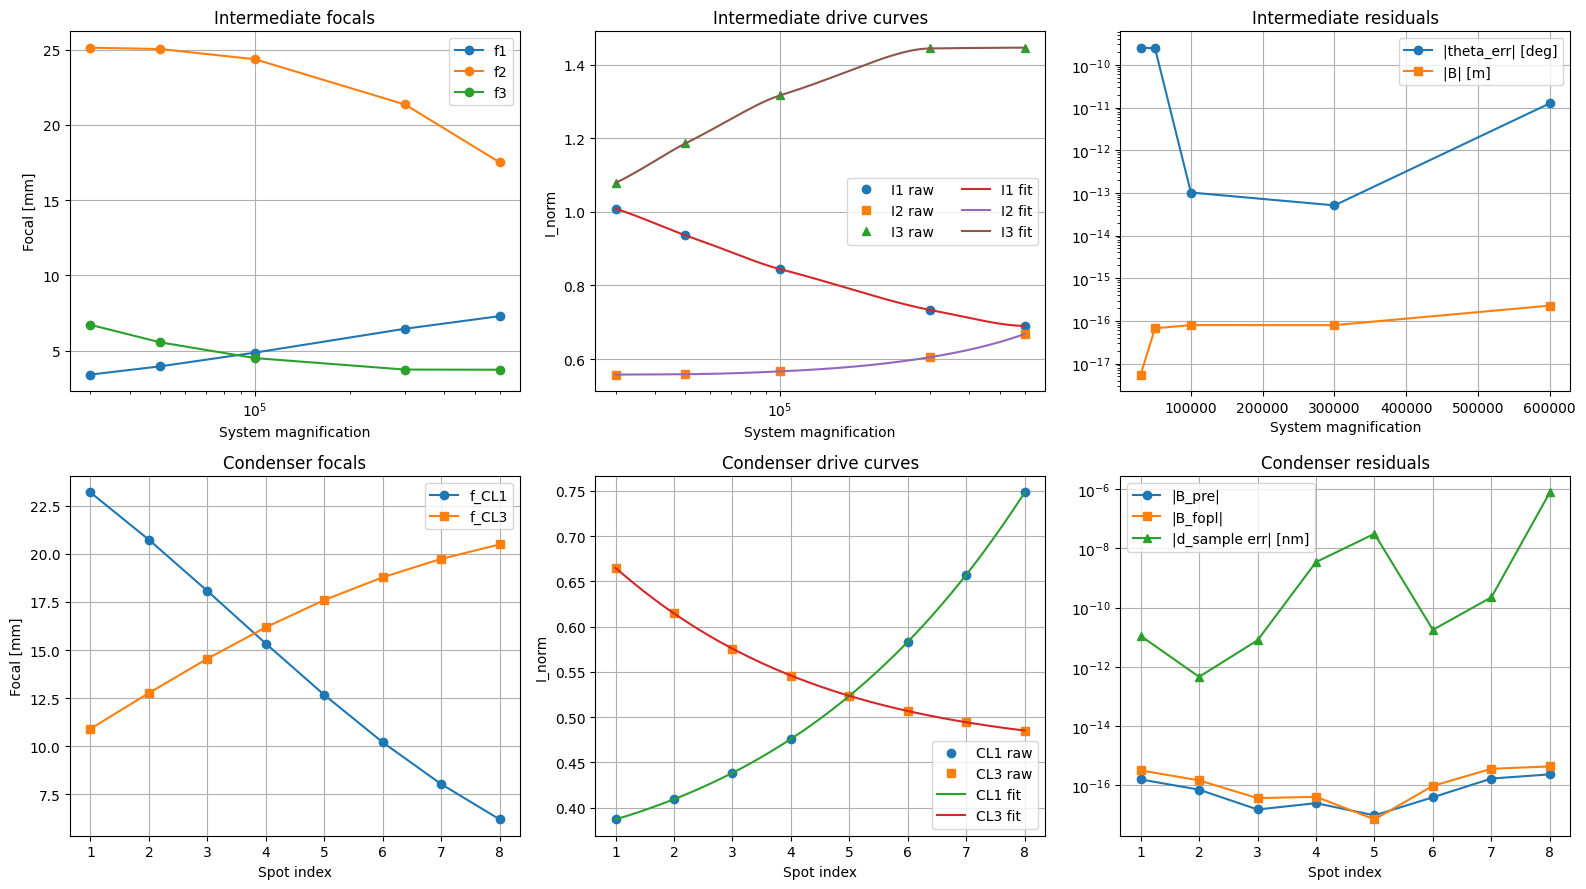

In [15]:
# Matrix-path consistency check (symbolic vs numeric) for pre-relay block
if use_symbolic_f1:
    d3o = drift_to_ocmini

    f3_probe = float(np.median(f3_scan))
    f1_probe = float(f1_from_f3_pre(f3_probe, geometry_cond, f_bounds_cond['CL1'], d_obj_cmini))

    M_pre_probe = system_matrix_pre(f1_probe, f3_probe, geometry_cond, d_obj_cmini)
    A_num, B_num, _, _ = extract_abcd(M_pre_probe)

    A_sym_probe = float(A_pre_from_f3_sym(
        f3_probe,
        geometry_cond['d_S_C1'],
        geometry_cond['d_C1_C3'],
        d3o,
    ))
    B_sym_probe = float(B_pre_from_f1f3_sym(
        f1_probe,
        f3_probe,
        geometry_cond['d_S_C1'],
        geometry_cond['d_C1_C3'],
        d3o,
    ))

    print('Matrix consistency (pre-relay probe):')
    print(f'  |A_num - A_sym| = {abs(A_num - A_sym_probe):.3e}')
    print(f'  |B_num - B_sym| = {abs(B_num - B_sym_probe):.3e}')


# Condenser validation checks
spot_idx_arr = np.array([r['spot_index'] for r in results_cond], dtype=float)
B_pre_arr = np.array([r['B_pre_residual'] for r in results_cond], dtype=float)
B_fopl_arr = np.array([r['B_fopl_residual'] for r in results_cond], dtype=float)
d_err_abs_arr = np.array([r['d_sample_err_abs_nm'] for r in results_cond], dtype=float)
d_err_rel_arr = np.array([r['d_sample_err_rel'] for r in results_cond], dtype=float)
f1_arr = np.array([r['f_CL1'] for r in results_cond], dtype=float)
f3_arr = np.array([r['f_CL3'] for r in results_cond], dtype=float)
I1_arr = np.array([r['I_norm_CL1'] for r in results_cond], dtype=float)
I3_arr = np.array([r['I_norm_CL3'] for r in results_cond], dtype=float)
AT1_arr = np.array([r['AT_CL1'] for r in results_cond], dtype=float)
AT3_arr = np.array([r['AT_CL3'] for r in results_cond], dtype=float)
A_pre_arr = np.array([r['A_pre_abs'] for r in results_cond], dtype=float)
d_sample_arr = np.array([r['d_sample_solved_nm'] for r in results_cond], dtype=float)
conv_arr = np.array([r['converged'] for r in results_cond], dtype=bool)

n_conv = int(conv_arr.sum())
max_B_pre = float(np.max(np.abs(B_pre_arr)))
max_B_fopl = float(np.max(np.abs(B_fopl_arr)))
max_d_rel = float(np.max(np.abs(d_err_rel_arr)))

all_i_bounds = bool(
    np.all((I1_arr >= I_norm_bounds_cond['CL1'][0]) & (I1_arr <= I_norm_bounds_cond['CL1'][1]))
    and np.all((I3_arr >= I_norm_bounds_cond['CL3'][0]) & (I3_arr <= I_norm_bounds_cond['CL3'][1]))
)
all_at_bounds = bool(
    np.all((AT1_arr >= AT_bounds_cond['CL1'][0]) & (AT1_arr <= AT_bounds_cond['CL1'][1]))
    and np.all((AT3_arr >= AT_bounds_cond['CL3'][0]) & (AT3_arr <= AT_bounds_cond['CL3'][1]))
)
strong_weak_f = float(np.mean((f1_arr < f3_arr).astype(float)))
strong_weak_i = float(np.mean((I1_arr > I3_arr).astype(float)))
max_f3_step = float(np.max(np.abs(np.diff(f3_arr)))) if len(f3_arr) > 1 else 0.0

corr_log = np.nan
if len(results_cond) > 1 and np.all(A_pre_arr > 0) and np.all(d_sample_arr > 0):
    corr_log = float(np.corrcoef(np.log(A_pre_arr), np.log(d_sample_arr))[0, 1])

print('\nCondenser validation summary:')
print(f'  Convergence: {n_conv}/{N_spots}')
print(f'  max |B_pre(S->O_Cmini)|: {max_B_pre:.3e} (tol {B_pre_tolerance:.1e})')
print(f'  max |B(S->F_OPL)|: {max_B_fopl:.3e} (tol {B_fopl_tolerance:.1e})')
print(f'  max relative sample-size error: {max_d_rel:.3e} (tol {sample_rel_tolerance:.1e})')
print(f'  All current bounds satisfied: {all_i_bounds}')
print(f'  All AT bounds satisfied: {all_at_bounds}')
print(f'  Strong/weak (f_CL1 < f_CL3 fraction): {strong_weak_f:.3f}')
print(f'  Strong/weak (I_norm_CL1 > I_norm_CL3 fraction): {strong_weak_i:.3f}')
print(f'  max |Δf_CL3| between adjacent spots: {max_f3_step*1e3:.3f} mm')
if np.isfinite(corr_log):
    print(f'  corr(log|A_pre|, log d_sample): {corr_log:.6f} (expected negative)')

if max_B_pre > B_pre_tolerance:
    print('WARNING: B_pre residual exceeds tolerance for at least one spot.')
if max_B_fopl > B_fopl_tolerance:
    print('WARNING: B(S->F_OPL) residual exceeds tolerance for at least one spot.')
if max_d_rel > sample_rel_tolerance:
    print('WARNING: sample-size target error exceeds tolerance for at least one spot.')
if not all_i_bounds or not all_at_bounds:
    print('WARNING: physics bounds violated in final table.')
if strong_weak_f < 0.75 or strong_weak_i < 0.75:
    print('WARNING: CL1-strong / CL3-weak trend is not dominant across the ladder.')
if np.isfinite(corr_log) and corr_log > -0.2:
    print('WARNING: weak inverse trend between |A_pre| and sample size.')


# Plot diagnostics for both modes
fig, axs = plt.subplots(2, 3, figsize=(16, 9))

# IL focals
f1_il_mm = np.array([r['f1_m'] for r in il_results]) * 1e3
f2_il_mm = np.array([r['f2_m'] for r in il_results]) * 1e3
f3_il_mm = np.array([r['f3_m'] for r in il_results]) * 1e3
axs[0, 0].semilogx(x_sys, f1_il_mm, 'o-', label='f1')
axs[0, 0].semilogx(x_sys, f2_il_mm, 'o-', label='f2')
axs[0, 0].semilogx(x_sys, f3_il_mm, 'o-', label='f3')
axs[0, 0].set_title('Intermediate focals')
axs[0, 0].set_xlabel('System magnification')
axs[0, 0].set_ylabel('Focal [mm]')
axs[0, 0].legend()

# IL currents + fits
axs[0, 1].semilogx(x_sys, I1_il, 'o', label='I1 raw')
axs[0, 1].semilogx(x_sys, I2_il, 's', label='I2 raw')
axs[0, 1].semilogx(x_sys, I3_il, '^', label='I3 raw')
axs[0, 1].semilogx(x_sys_dense, I1_il_dense, '-', label='I1 fit')
axs[0, 1].semilogx(x_sys_dense, I2_il_dense, '-', label='I2 fit')
axs[0, 1].semilogx(x_sys_dense, I3_il_dense, '-', label='I3 fit')
axs[0, 1].set_title('Intermediate drive curves')
axs[0, 1].set_xlabel('System magnification')
axs[0, 1].set_ylabel('I_norm')
axs[0, 1].legend(ncol=2)

# IL residuals
theta_err_deg = np.rad2deg(np.array([r['theta_err'] for r in il_results]))
B_il = np.abs(np.array([r['B_m'] for r in il_results]))
axs[0, 2].semilogy(x_sys, np.maximum(np.abs(theta_err_deg), 1e-20), 'o-', label='|theta_err| [deg]')
axs[0, 2].semilogy(x_sys, np.maximum(B_il, 1e-20), 's-', label='|B| [m]')
axs[0, 2].set_title('Intermediate residuals')
axs[0, 2].set_xlabel('System magnification')
axs[0, 2].legend()

# Condenser focals
axs[1, 0].plot(spot_idx_arr, f1_arr * 1e3, 'o-', label='f_CL1')
axs[1, 0].plot(spot_idx_arr, f3_arr * 1e3, 's-', label='f_CL3')
axs[1, 0].set_title('Condenser focals')
axs[1, 0].set_xlabel('Spot index')
axs[1, 0].set_ylabel('Focal [mm]')
axs[1, 0].legend()

# Condenser current curves
axs[1, 1].plot(spot_idx_arr, I1_arr, 'o', label='CL1 raw')
axs[1, 1].plot(spot_idx_arr, I3_arr, 's', label='CL3 raw')
axs[1, 1].plot(spot_dense, I1_cond_dense, '-', label='CL1 fit')
axs[1, 1].plot(spot_dense, I3_cond_dense, '-', label='CL3 fit')
axs[1, 1].set_title('Condenser drive curves')
axs[1, 1].set_xlabel('Spot index')
axs[1, 1].set_ylabel('I_norm')
axs[1, 1].legend()

# Condenser residuals / sample error
axs[1, 2].semilogy(spot_idx_arr, np.maximum(np.abs(B_pre_arr), 1e-20), 'o-', label='|B_pre|')
axs[1, 2].semilogy(spot_idx_arr, np.maximum(np.abs(B_fopl_arr), 1e-20), 's-', label='|B_fopl|')
axs[1, 2].semilogy(spot_idx_arr, np.maximum(np.abs(d_err_abs_arr), 1e-20), '^-', label='|d_sample err| [nm]')
axs[1, 2].set_title('Condenser residuals')
axs[1, 2].set_xlabel('Spot index')
axs[1, 2].legend()

fig.tight_layout()
plt.show()


## 8) ObjPost + PL1 Compensation And Curve Export

This block computes full EM compensation curves for `ObjPost` and `PL1` from IL ampere-turn cancellation,
 derives per-control `Gc` scales from focal priors, and exports a reusable NPZ artifact.


In [16]:
from pathlib import Path
import json

from temgym_core.constants import compute_I0_Gc_from_focal_rotation

# -------------------------------------------------
# ObjPost / PL1 compensation from IL NI cancellation
# -------------------------------------------------
turns_objpost = 3000.0
turns_pl1 = 2000.0
ni_split_objpost = 0.7
ni_split_pl1 = 0.3

f_objpost_target_m = 2.3e-3  # hard prior
f_pl1_target_m = float(np.clip(5.0e-3 * (100.0 / float(M_proj)), 3.0e-3, 10.0e-3))

x_sys = np.array(target_system_mags, dtype=float)
ni_il_total = np.array([r['AT1'] + r['AT2'] + r['AT3'] for r in il_results], dtype=float)
ni_comp_total = -ni_il_total
ni_objpost = ni_split_objpost * ni_comp_total
ni_pl1 = ni_split_pl1 * ni_comp_total

# Signed normalized currents (allowed in phase-2 model API)
i_norm_objpost = ni_objpost / (turns_objpost * I_fs_A)
i_norm_pl1 = ni_pl1 / (turns_pl1 * I_fs_A)

rot_objpost_target = Rc_phys * ni_objpost
rot_pl1_target = Rc_phys * ni_pl1


def _solve_i0_gc_series(rotation_targets, focal_target, rc):
    i0_out = np.zeros_like(rotation_targets, dtype=float)
    gc_out = np.zeros_like(rotation_targets, dtype=float)
    for idx, psi in enumerate(rotation_targets):
        if abs(float(psi)) < 1e-15:
            i0_out[idx] = 0.0
            gc_out[idx] = np.nan
            continue
        i0_i, gc_i = compute_I0_Gc_from_focal_rotation(
            focal_length=float(focal_target),
            rotation_angle=float(psi),
            Rc=float(rc),
        )
        i0_out[idx] = float(i0_i)
        gc_out[idx] = float(gc_i)
    return i0_out, gc_out


i0_objpost_req, gc_objpost_req = _solve_i0_gc_series(rot_objpost_target, f_objpost_target_m, Rc_phys)
i0_pl1_req, gc_pl1_req = _solve_i0_gc_series(rot_pl1_target, f_pl1_target_m, Rc_phys)

if np.any(~np.isfinite(gc_objpost_req)) or np.any(~np.isfinite(gc_pl1_req)):
    raise RuntimeError('Non-finite required Gc in compensation solve.')

# Base Gc for runtime lens configs + per-control scales
Gc_objpost_base = float(np.median(gc_objpost_req))
Gc_pl1_base = float(np.median(gc_pl1_req))

gc_scale_objpost = gc_objpost_req / Gc_objpost_base
gc_scale_pl1 = gc_pl1_req / Gc_pl1_base

# Realized focal/rotation consistency checks
f_objpost_realized = 1.0 / (gc_objpost_req * np.maximum(np.abs(i0_objpost_req), 1e-30) ** 2)
f_pl1_realized = 1.0 / (gc_pl1_req * np.maximum(np.abs(i0_pl1_req), 1e-30) ** 2)

theta_il = Rc_phys * ni_il_total
theta_comp = Rc_phys * (ni_objpost + ni_pl1)
theta_net = theta_il + theta_comp

pl1_bounds_ok = bool(np.all((f_pl1_realized >= 3.0e-3) & (f_pl1_realized <= 10.0e-3)))
objpost_ok = bool(np.allclose(f_objpost_realized, f_objpost_target_m, rtol=1e-8, atol=1e-12))

comp_df = pd.DataFrame({
    'M_system': x_sys,
    'NI_IL_total': ni_il_total,
    'NI_ObjPost': ni_objpost,
    'NI_PL1': ni_pl1,
    'I_norm_ObjPost': i_norm_objpost,
    'I_norm_PL1': i_norm_pl1,
    'I0_ObjPost_req': i0_objpost_req,
    'I0_PL1_req': i0_pl1_req,
    'Gc_ObjPost_req': gc_objpost_req,
    'Gc_PL1_req': gc_pl1_req,
    'GcScale_ObjPost': gc_scale_objpost,
    'GcScale_PL1': gc_scale_pl1,
    'f_ObjPost_realized_m': f_objpost_realized,
    'f_PL1_realized_m': f_pl1_realized,
    'theta_IL_rad': theta_il,
    'theta_comp_rad': theta_comp,
    'theta_net_rad': theta_net,
})

with pd.option_context('display.max_columns', None, 'display.float_format', '{:.9e}'.format):
    display(comp_df)

print('Compensation checks:')
print(f'  max |theta_net| [rad]: {np.max(np.abs(theta_net)):.3e}')
print(f'  ObjPost focal target met: {objpost_ok}')
print(f'  PL1 focal bounds [3,10] mm satisfied: {pl1_bounds_ok}')

# -------------------------------------------------
# Curve export (NPZ + metadata JSON)
# -------------------------------------------------
spot_idx_export = np.array([r['spot_index'] for r in results_cond], dtype=float)
spot_norm_currents_export = np.column_stack([
    np.array([r['I_norm_CL1'] for r in results_cond], dtype=float),
    np.array([r['I_norm_CL3'] for r in results_cond], dtype=float),
])
spot_sample_size_nm_export = np.array([r['d_sample_solved_nm'] for r in results_cond], dtype=float)

mag_norm_currents_il_export = np.column_stack([
    np.array([r['I1_norm'] for r in il_results], dtype=float),
    np.array([r['I2_norm'] for r in il_results], dtype=float),
    np.array([r['I3_norm'] for r in il_results], dtype=float),
])

mag_norm_currents_comp_export = np.column_stack([
    i_norm_objpost,
    i_norm_pl1,
])

mag_gc_scales_comp_export = np.column_stack([
    gc_scale_objpost,
    gc_scale_pl1,
])

# Canonical z-layout for runtime notebook assembly (source at z=0)
z_source = 0.0
z_cl1 = z_source + geometry_cond['d_S_C1']
z_cl3 = z_cl1 + geometry_cond['d_C1_C3']
z_cmini = z_cl3 + geometry_cond['d_C3_A'] + geometry_cond['d_A_Cmini']
z_objpost = z_cmini + geometry_cond['d_Cmini_OPL']
z_sample = z_objpost - sample_distance_from_opl_m
z_objpre = z_sample - sample_distance_from_opl_m
z_il1 = z_objpost + geometry_il['d_obj_to_il1']
z_il2 = z_il1 + geometry_il['d_il1_to_il2']
z_il3 = z_il2 + geometry_il['d_il2_to_il3']
z_pl1 = z_il3 + geometry_il['d_il3_to_image']
z_screen = z_pl1 + geometry_il['d_il3_to_image']

if not (z_cmini < z_objpre < z_sample < z_objpost < z_il1):
    raise ValueError(
        'Invalid objective/sample ordering: expected Cmini < ObjPre < Sample < ObjPost < IL1.'
    )

metadata = {
    'schema_version': 1,
    'voltage_V': float(U_accel_V),
    'full_scale_current_A': float(I_fs_A),
    'Rc_phys_rad_per_AT': float(Rc_phys),
    'M_obj': float(M_obj),
    'M_proj': float(M_proj),
    'geometry_cond': {k: float(v) for k, v in geometry_cond.items()},
    'geometry_il': {k: float(v) for k, v in geometry_il.items()},
    'sample_distance_from_opl_m': float(sample_distance_from_opl_m),
    'f_cmini_fixed_m': float(geometry_cond['f_Cmini']),
    'f_objpost_target_m': float(f_objpost_target_m),
    'f_pl1_target_m': float(f_pl1_target_m),
    'turns': {
        'CL1': float(turns_cond['CL1']),
        'CL3': float(turns_cond['CL3']),
        'IL1': float(turns_il['IL1']),
        'IL2': float(turns_il['IL2']),
        'IL3': float(turns_il['IL3']),
        'ObjPost': float(turns_objpost),
        'PL1': float(turns_pl1),
    },
    'Gc_base': {
        'CL1': float(Gc_phys_cond['CL1']),
        'CL3': float(Gc_phys_cond['CL3']),
        'IL1': float(Gc_phys_il['IL1']),
        'IL2': float(Gc_phys_il['IL2']),
        'IL3': float(Gc_phys_il['IL3']),
        'ObjPost': float(Gc_objpost_base),
        'PL1': float(Gc_pl1_base),
    },
    'ni_split': {
        'objpost': float(ni_split_objpost),
        'pl1': float(ni_split_pl1),
    },
    'z_positions_m': {
        'Source': float(z_source),
        'CL1': float(z_cl1),
        'CL3': float(z_cl3),
        'Cmini': float(z_cmini),
        'ObjPre': float(z_objpre),
        'Sample': float(z_sample),
        'ObjPost': float(z_objpost),
        'IL1': float(z_il1),
        'IL2': float(z_il2),
        'IL3': float(z_il3),
        'PL1': float(z_pl1),
        'Screen': float(z_screen),
    },
}

repo_root = Path.cwd()
if not (repo_root / 'src').exists() and (repo_root.parent / 'src').exists():
    repo_root = repo_root.parent

export_dir = repo_root / 'examples/microscope_models/data'
export_dir.mkdir(parents=True, exist_ok=True)
export_path = export_dir / 'microscope_design_curves.npz'

np.savez(
    export_path,
    metadata_json=np.array(json.dumps(metadata), dtype=object),
    spot_control_values=spot_idx_export,
    spot_norm_currents=spot_norm_currents_export,
    spot_sample_size_nm=spot_sample_size_nm_export,
    mag_control_values=x_sys,
    mag_norm_currents_il=mag_norm_currents_il_export,
    mag_norm_currents_comp=mag_norm_currents_comp_export,
    mag_gc_scales_comp=mag_gc_scales_comp_export,
    mag_theta_net=theta_net,
    fit_spot_dense_x=spot_dense,
    fit_spot_dense_cl1=I1_cond_dense,
    fit_spot_dense_cl3=I3_cond_dense,
    fit_mag_dense_x=x_sys_dense,
    fit_mag_dense_il1=I1_il_dense,
    fit_mag_dense_il2=I2_il_dense,
    fit_mag_dense_il3=I3_il_dense,
)

print(f'Exported curve package: {export_path}')
print('  spot_norm_currents shape:', spot_norm_currents_export.shape)
print('  mag_norm_currents_il shape:', mag_norm_currents_il_export.shape)
print('  mag_norm_currents_comp shape:', mag_norm_currents_comp_export.shape)
print('  mag_gc_scales_comp shape:', mag_gc_scales_comp_export.shape)


,M_system,NI_IL_total,NI_ObjPost,NI_PL1,I_norm_ObjPost,I_norm_PL1,I0_ObjPost_req,I0_PL1_req,Gc_ObjPost_req,Gc_PL1_req,GcScale_ObjPost,GcScale_PL1,f_ObjPost_realized_m,f_PL1_realized_m,theta_IL_rad,theta_comp_rad,theta_net_rad
0,3.000000000e+04,1.260000000e+04,-8.820000000e+03,-3.780000000e+03,-1.470000000e+00,-9.450000000e-01,-8.820000000e+03,-3.780000000e+03,5.589011378e-06,1.399736849e-05,1.000000000e+00,1.000000000e+00,2.300000000e-03,5.000000000e-03,6.679897592e+00,-6.679897592e+00,0.000000000e+00
1,5.000000000e+04,1.260000000e+04,-8.820000000e+03,-3.780000000e+03,-1.470000000e+00,-9.450000000e-01,-8.820000000e+03,-3.780000000e+03,5.589011378e-06,1.399736849e-05,1.000000000e+00,1.000000000e+00,2.300000000e-03,5.000000000e-03,6.679897592e+00,-6.679897592e+00,8.881784197e-16
2,1.000000000e+05,1.260000000e+04,-8.820000000e+03,-3.780000000e+03,-1.470000000e+00,-9.450000000e-01,-8.820000000e+03,-3.780000000e+03,5.589011378e-06,1.399736849e-05,1.000000000e+00,1.000000000e+00,2.300000000e-03,5.000000000e-03,6.679897592e+00,-6.679897592e+00,0.000000000e+00
3,3.000000000e+05,1.260000000e+04,-8.820000000e+03,-3.780000000e+03,-1.470000000e+00,-9.450000000e-01,-8.820000000e+03,-3.780000000e+03,5.589011378e-06,1.399736849e-05,1.000000000e+00,1.000000000e+00,2.300000000e-03,5.000000000e-03,6.679897592e+00,-6.679897592e+00,0.000000000e+00
4,6.000000000e+05,1.260000000e+04,-8.820000000e+03,-3.780000000e+03,-1.470000000e+00,-9.450000000e-01,-8.820000000e+03,-3.780000000e+03,5.589011378e-06,1.399736849e-05,1.000000000e+00,1.000000000e+00,2.300000000e-03,5.000000000e-03,6.679897592e+00,-6.679897592e+00,0.000000000e+00


Compensation checks:
  max |theta_net| [rad]: 8.882e-16
  ObjPost focal target met: True
  PL1 focal bounds [3,10] mm satisfied: True
Exported curve package: /home/dl277493/Documents/Code/TemGymCore/examples/microscope_models/examples/microscope_models/data/microscope_design_curves.npz
  spot_norm_currents shape: (8, 2)
  mag_norm_currents_il shape: (5, 3)
  mag_norm_currents_comp shape: (5, 2)
  mag_gc_scales_comp shape: (5, 2)
